# Notebook 05 — Comparación Final: BoW vs. Word2Vec vs. BERT

**Proyecto 2:** Análisis Semántico de Letras Musicales  
**Curso:** Minería de Textos — Colegio Universitario de Cartago (CUC)
---




## 1. Imports y configuración

In [1]:
import warnings, os, sys
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath('../../../..'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, classification_report,
    silhouette_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder, normalize

from pymongo import MongoClient

# ── Paleta de colores consistente con Notebooks 03 y 04 ───────────────────────
PALETTE = [
    '#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6',
    '#1abc9c','#e67e22','#34495e','#e91e63','#00bcd4'
]
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor'  : '#f8f9fa',
    'axes.grid'       : True,
    'grid.alpha'      : 0.4,
    'font.family'     : 'DejaVu Sans',
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✓ Imports OK')

✓ Imports OK


---
## 2. Carga de datos desde MongoDB


In [2]:
# ── Conexión a MongoDB ─────────────────────────────────────────────────────────
try:
    client    = MongoClient('mongodb://localhost:27017/', serverSelectionTimeoutMS=5000)
    client.admin.command('ping')
    print('✓ Conexión a MongoDB OK')
except Exception as e:
    raise RuntimeError(
        f'No se pudo conectar a MongoDB: {e}\n'
        '  Verificá que mongod esté corriendo en localhost:27017'
    ) from e

db        = client['musica']
coleccion = db['canciones']

# ── Extraer canciones con los tres embeddings disponibles ─────────────────────
filtro = {
    'Lyrics'                   : {'$exists': True, '$ne': ''},
    'Genre'                    : {'$exists': True},
    'embeddings.word2vec_avg'  : {'$exists': True},
    'embeddings.beto_cls'      : {'$exists': True},
}
proyeccion = {
    '_id': 0, 'Song': 1, 'Artist': 1, 'Genre': 1,
    'Lyrics': 1,
    'embeddings.word2vec_avg': 1,
    'embeddings.beto_cls'    : 1,
}

docs = list(coleccion.find(filtro, proyeccion))
df   = pd.DataFrame(docs).dropna(subset=['Genre', 'Lyrics']).copy()
df   = df[df['Lyrics'].str.strip().str.len() > 50].reset_index(drop=True)

# Géneros dinámicos (mínimo 20 canciones)
conteo  = df['Genre'].value_counts()
GENEROS = conteo[conteo >= 20].index.tolist()
df      = df[df['Genre'].isin(GENEROS)].reset_index(drop=True)

print(f'\n{len(df):,} canciones con los tres embeddings | {len(GENEROS)} géneros\n')
print(df['Genre'].value_counts().to_string())

✓ Conexión a MongoDB OK

9,228 canciones con los tres embeddings | 10 géneros

Genre
Rock          1410
Pop           1307
Hip-Hop       1159
Country       1010
Metal         1008
Jazz           844
Electronic     804
R&B            681
Indie          510
Folk           495


In [3]:
# ── Construir matrices de representación ──────────────────────────────────────

# 1. TF-IDF  (BoW pesado por frecuencia inversa de documento)
print('Construyendo matriz TF-IDF...')
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents='unicode',
    token_pattern=r'\b[a-zA-ZáéíóúüñÁÉÍÓÚÜÑ]{3,}\b'
)
X_bow  = tfidf.fit_transform(df['Lyrics']).toarray().astype(np.float32)
print(f'  ✓ TF-IDF  — shape: {X_bow.shape}')

# 2. Word2Vec (embeddings guardados en Notebook 03)
X_w2v = np.vstack(df['embeddings'].apply(lambda e: e['word2vec_avg']).tolist()).astype(np.float32)
print(f'  ✓ Word2Vec — shape: {X_w2v.shape}')

# 3. BERT [CLS] (embeddings guardados en Notebook 04)
X_beto = np.vstack(df['embeddings'].apply(lambda e: e['beto_cls']).tolist()).astype(np.float32)
print(f'  ✓ BERT    — shape: {X_beto.shape}')

# ── Etiquetas ─────────────────────────────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(df['Genre'])
print(f'\nClases: {list(le.classes_)}')

Construyendo matriz TF-IDF...
  ✓ TF-IDF  — shape: (9228, 5000)
  ✓ Word2Vec — shape: (9228, 100)
  ✓ BERT    — shape: (9228, 768)

Clases: ['Country', 'Electronic', 'Folk', 'Hip-Hop', 'Indie', 'Jazz', 'Metal', 'Pop', 'R&B', 'Rock']


---
## 3. Clasificación de género musical

Comparamos las tres representaciones como features de entrada para dos clasificadores clásicos:  
- **Logistic Regression** — lineal, rápido, baseline estándar  
- **KNN (k=5)** — no paramétrico, sensible a la geometría del espacio de embeddings  


In [4]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(sss.split(X_bow, y))

REPRESENTACIONES = {
    'TF-IDF (BoW)' : X_bow,
    'Word2Vec'     : X_w2v,
    'BERT'         : X_beto,
}

CLASIFICADORES = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=1.0),
    'KNN (k=5)'          : KNeighborsClassifier(n_neighbors=5, metric='cosine'),
}

resultados_clf = {}   # { repr_name: { clf_name: accuracy } }
reports_clf    = {}   # para mostrar classification_report

for repr_name, X in REPRESENTACIONES.items():
    resultados_clf[repr_name] = {}
    reports_clf[repr_name]    = {}
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Normalizar a norma unitaria (mejor para distancia coseno con KNN y LR)
    X_train_n = normalize(X_train)
    X_test_n  = normalize(X_test)

    for clf_name, clf in CLASIFICADORES.items():
        clf.fit(X_train_n, y_train)
        y_pred = clf.predict(X_test_n)
        acc    = accuracy_score(y_test, y_pred)
        resultados_clf[repr_name][clf_name] = round(acc, 4)
        reports_clf[repr_name][clf_name]    = classification_report(
            y_test, y_pred, target_names=le.classes_, zero_division=0
        )
        print(f'  [{repr_name:<18}] {clf_name:<25} → Accuracy: {acc:.4f} ({acc*100:.1f}%)')

print('\n✓ Clasificación completada')

  [TF-IDF (BoW)      ] Logistic Regression       → Accuracy: 0.4074 (40.7%)
  [TF-IDF (BoW)      ] KNN (k=5)                 → Accuracy: 0.2941 (29.4%)
  [Word2Vec          ] Logistic Regression       → Accuracy: 0.3954 (39.5%)
  [Word2Vec          ] KNN (k=5)                 → Accuracy: 0.3104 (31.0%)
  [BERT              ] Logistic Regression       → Accuracy: 0.4122 (41.2%)
  [BERT              ] KNN (k=5)                 → Accuracy: 0.3283 (32.8%)

✓ Clasificación completada



=== Accuracy por representación y clasificador ===

                Logistic Regression  KNN (k=5)
Representación                                
TF-IDF (BoW)                 0.4074     0.2941
Word2Vec                     0.3954     0.3104
BERT                         0.4122     0.3283


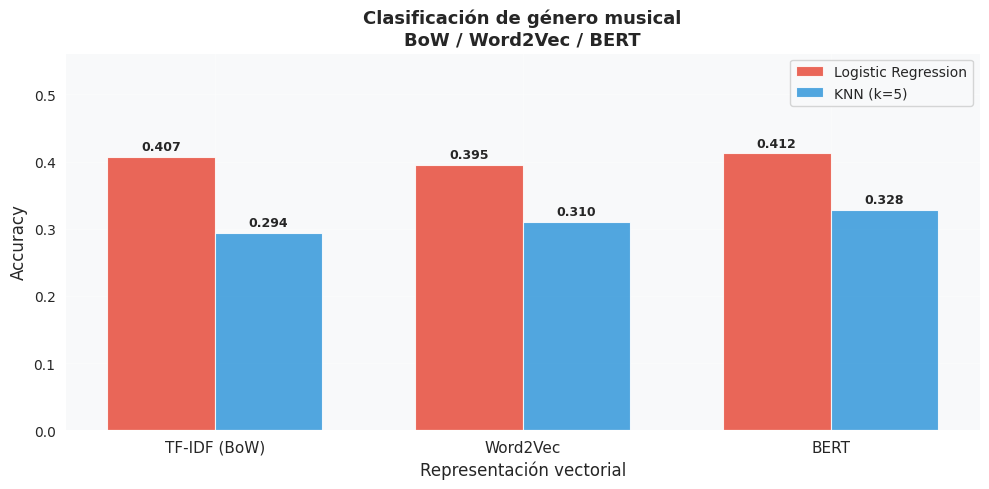

✓ Figura guardada en docs/comparacion_clasificacion.png


In [5]:
# ── Tabla de accuracy ─────────────────────────────────────────────────────────
df_acc = pd.DataFrame(resultados_clf).T
df_acc.index.name = 'Representación'
print('\n=== Accuracy por representación y clasificador ===\n')
print(df_acc.to_string())

# ── Gráfico de barras agrupadas ───────────────────────────────────────────────
x     = np.arange(len(df_acc))
width = 0.35
clfs  = list(CLASIFICADORES.keys())

fig, ax = plt.subplots(figsize=(10, 5))
for i, clf_name in enumerate(clfs):
    bars = ax.bar(
        x + i * width,
        df_acc[clf_name].values,
        width,
        label=clf_name,
        color=PALETTE[i],
        alpha=0.85,
        edgecolor='white',
        linewidth=0.8,
    )
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.005,
            f'{h:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

ax.set_xlabel('Representación vectorial', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Clasificación de género musical\nBoW / Word2Vec / BERT', fontsize=13, fontweight='bold')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(df_acc.index, fontsize=11)
ax.set_ylim(0, min(1.0, df_acc.values.max() + 0.15))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../docs/comparacion_clasificacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figura guardada en docs/comparacion_clasificacion.png')

Mostrando matrices de confusión con: Logistic Regression



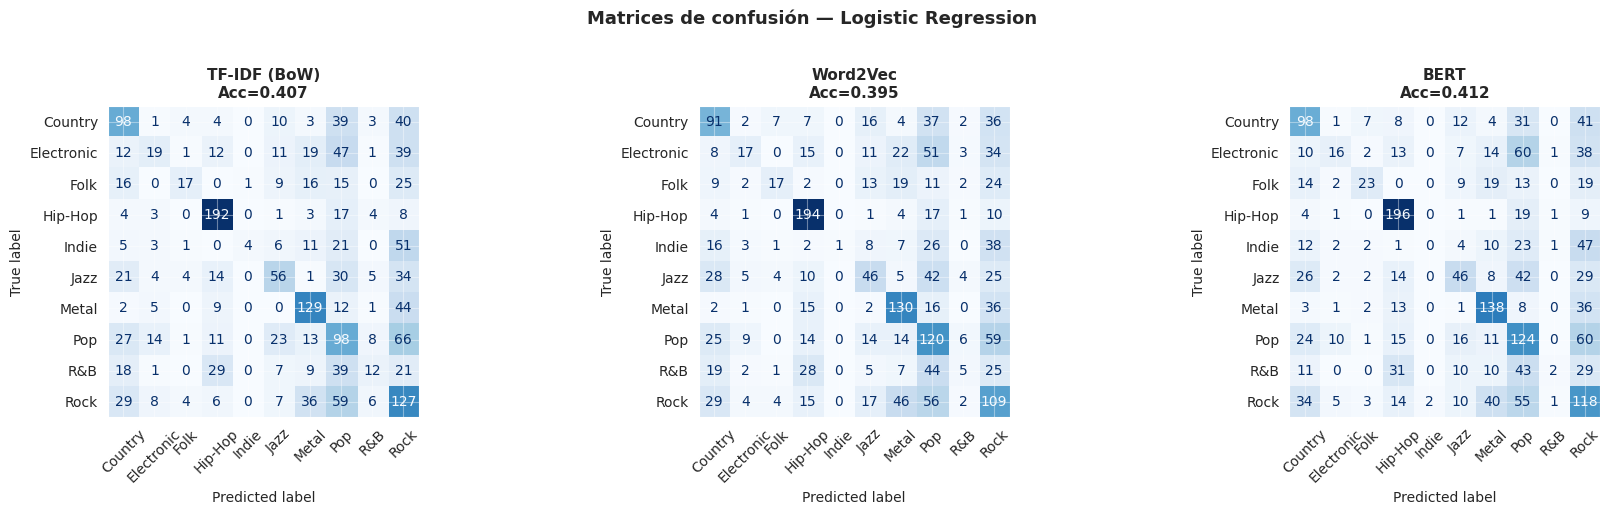

In [6]:
# ── Matrices de confusión para el mejor clasificador por representación ────────
mejor_clf_nombre = max(CLASIFICADORES.keys(),
                       key=lambda c: df_acc[c].max())
print(f'Mostrando matrices de confusión con: {mejor_clf_nombre}\n')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (repr_name, X) in zip(axes, REPRESENTACIONES.items()):
    X_train_n = normalize(X[train_idx])
    X_test_n  = normalize(X[test_idx])
    clf = CLASIFICADORES[mejor_clf_nombre]
    clf.fit(X_train_n, y[train_idx])
    y_pred = clf.predict(X_test_n)
    cm = confusion_matrix(y[test_idx], y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
    ax.set_title(f'{repr_name}\nAcc={accuracy_score(y[test_idx], y_pred):.3f}',
                 fontsize=11, fontweight='bold')

plt.suptitle(f'Matrices de confusión — {mejor_clf_nombre}', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../docs/comparacion_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ── Classification report detallado del mejor clasificador ────────────────────
print(f'=== Classification Report detallado — {mejor_clf_nombre} ===\n')
for repr_name in REPRESENTACIONES:
    print(f'── {repr_name} ──')
    print(reports_clf[repr_name][mejor_clf_nombre])
    print()

=== Classification Report detallado — Logistic Regression ===

── TF-IDF (BoW) ──
              precision    recall  f1-score   support

     Country       0.42      0.49      0.45       202
  Electronic       0.33      0.12      0.17       161
        Folk       0.53      0.17      0.26        99
     Hip-Hop       0.69      0.83      0.75       232
       Indie       0.80      0.04      0.07       102
        Jazz       0.43      0.33      0.37       169
       Metal       0.54      0.64      0.58       202
         Pop       0.26      0.38      0.31       261
         R&B       0.30      0.09      0.14       136
        Rock       0.28      0.45      0.34       282

    accuracy                           0.41      1846
   macro avg       0.46      0.35      0.35      1846
weighted avg       0.43      0.41      0.38      1846


── Word2Vec ──
              precision    recall  f1-score   support

     Country       0.39      0.45      0.42       202
  Electronic       0.37      0.11 

---
## 4. Clustering K-Means + Silhouette Score

Evaluamos la **coherencia interna** de los clusters formados por cada representación,  
sin usar las etiquetas de género durante el clustering.

El **Silhouette Score** mide qué tan bien separados están los clusters:  
- Valor cercano a **+1** → clusters bien definidos y separados  
- Valor cercano a **0** → clusters solapados  
- Valor negativo → puntos asignados al cluster equivocado

In [8]:
N_CLUSTERS = len(GENEROS)
resultados_sil = {}   # { repr_name: silhouette_score }
etiquetas_km   = {}   # { repr_name: array de cluster labels }

# Para t-SNE posterior, también calculamos sobre submuestra si el dataset es grande
N_MAX_SIL = 2000   # límite para Silhouette (costoso en O(n^2))

for repr_name, X in REPRESENTACIONES.items():
    X_n = normalize(X)   # norma unitaria

    km = KMeans(
        n_clusters=N_CLUSTERS,
        random_state=RANDOM_STATE,
        n_init=10,
        max_iter=300,
    )
    labels = km.fit_predict(X_n)
    etiquetas_km[repr_name] = labels

    # Silhouette sobre submuestra si hay muchos puntos
    n = min(N_MAX_SIL, len(X_n))
    idx_sil = np.random.choice(len(X_n), n, replace=False)
    sil = silhouette_score(X_n[idx_sil], labels[idx_sil], metric='cosine')
    resultados_sil[repr_name] = round(float(sil), 4)
    print(f'  [{repr_name:<18}] Silhouette Score = {sil:.4f}')

print('\n✓ Clustering completado')

  [TF-IDF (BoW)      ] Silhouette Score = 0.0001
  [Word2Vec          ] Silhouette Score = 0.0556
  [BERT              ] Silhouette Score = 0.0682

✓ Clustering completado


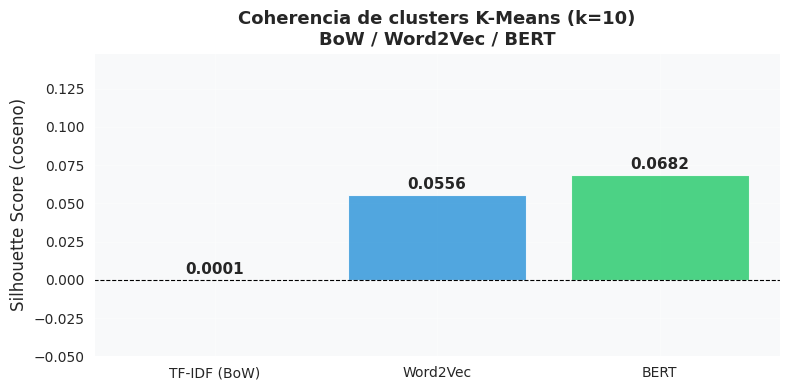

✓ Figura guardada en docs/comparacion_silhouette.png


In [9]:
# ── Gráfico de barras — Silhouette Score ──────────────────────────────────────
nombres_repr = list(resultados_sil.keys())
sil_vals     = [resultados_sil[r] for r in nombres_repr]
colores_sil  = PALETTE[:len(nombres_repr)]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(nombres_repr, sil_vals, color=colores_sil, alpha=0.85,
              edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, sil_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'{val:.4f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Silhouette Score (coseno)', fontsize=12)
ax.set_title(f'Coherencia de clusters K-Means (k={N_CLUSTERS})\nBoW / Word2Vec / BERT',
             fontsize=13, fontweight='bold')
ax.set_ylim(min(-0.05, min(sil_vals) - 0.05), max(sil_vals) + 0.08)
plt.tight_layout()
plt.savefig('../docs/comparacion_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figura guardada en docs/comparacion_silhouette.png')

---
## 5. Visualización t-SNE comparativa


In [10]:
N_TSNE = min(1000, len(df))
idx_tsne = np.random.choice(len(df), N_TSNE, replace=False)
df_sub   = df.iloc[idx_tsne].reset_index(drop=True)
y_sub    = y[idx_tsne]

coords_tsne = {}
for repr_name, X in REPRESENTACIONES.items():
    print(f'Calculando t-SNE para {repr_name}...')
    X_sub_n = normalize(X[idx_tsne])
    coords  = TSNE(
        n_components=2,
        random_state=RANDOM_STATE,
        perplexity=40,
        max_iter=1000,
        init='pca',
        learning_rate='auto',
    ).fit_transform(X_sub_n)
    coords_tsne[repr_name] = coords
    print(f'  ✓ t-SNE completo — shape: {coords.shape}')

print('\n✓ Todas las proyecciones t-SNE calculadas')

Calculando t-SNE para TF-IDF (BoW)...
  ✓ t-SNE completo — shape: (1000, 2)
Calculando t-SNE para Word2Vec...
  ✓ t-SNE completo — shape: (1000, 2)
Calculando t-SNE para BERT...
  ✓ t-SNE completo — shape: (1000, 2)

✓ Todas las proyecciones t-SNE calculadas


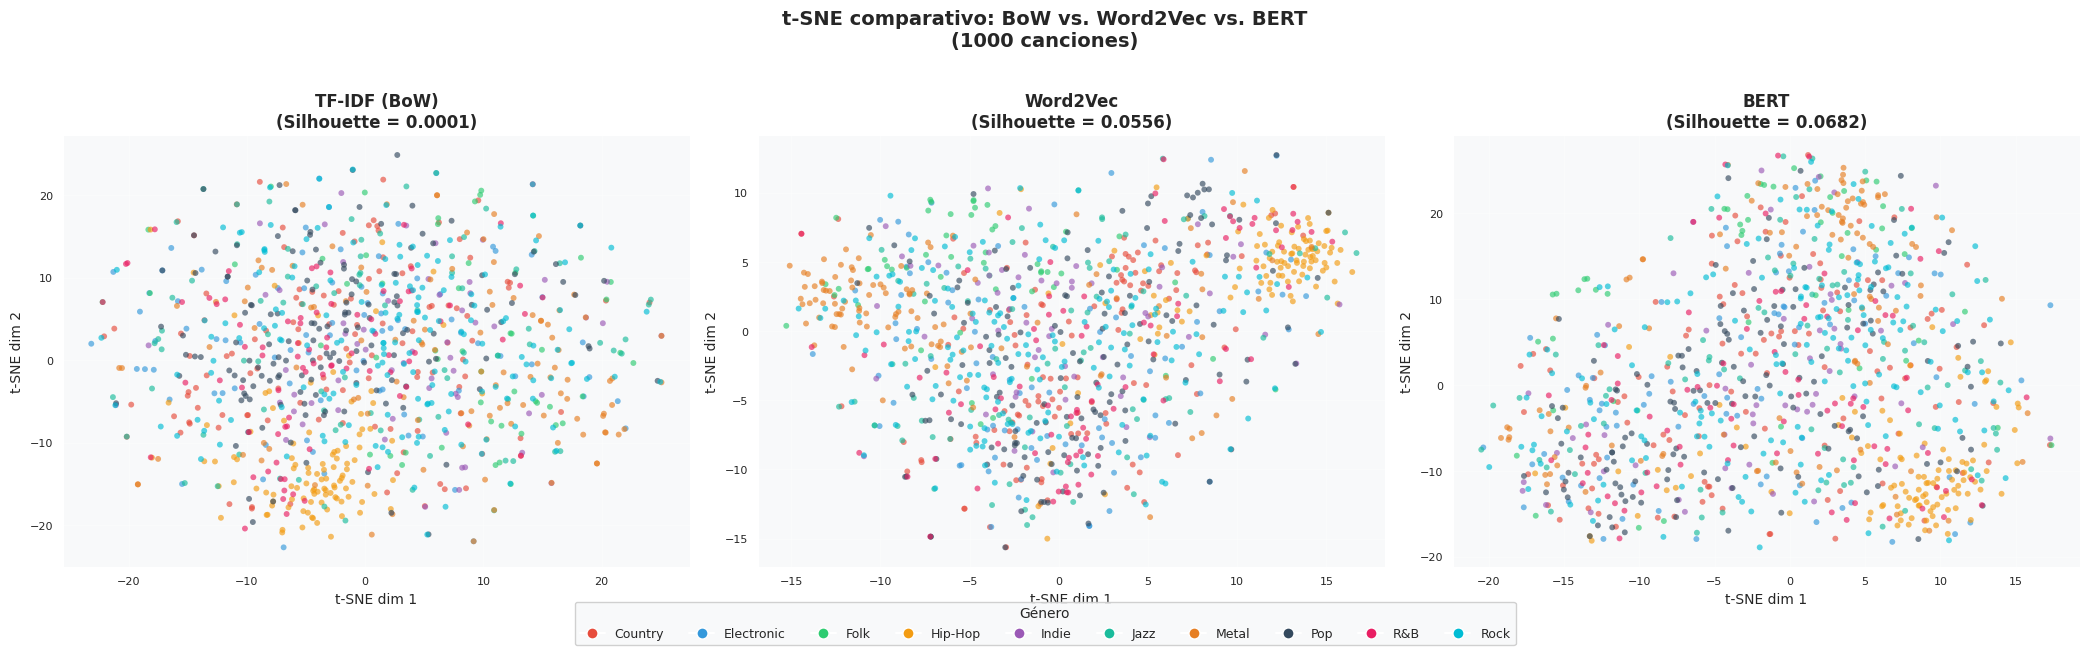

✓ Figura guardada en docs/comparacion_tsne.png


In [11]:
# ── Panel comparativo t-SNE 1×3 ──────────────────────────────────────────────
genero_labels = le.inverse_transform(y_sub)
color_map     = {g: PALETTE[i % len(PALETTE)] for i, g in enumerate(sorted(GENEROS))}
colores_pts   = [color_map[g] for g in genero_labels]

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, repr_name in zip(axes, REPRESENTACIONES.keys()):
    coords = coords_tsne[repr_name]
    for g in sorted(GENEROS):
        mask = genero_labels == g
        ax.scatter(
            coords[mask, 0], coords[mask, 1],
            c=color_map[g], label=g, s=18, alpha=0.65, edgecolors='none'
        )
    sil_val = resultados_sil[repr_name]
    ax.set_title(
        f'{repr_name}\n(Silhouette = {sil_val:.4f})',
        fontsize=12, fontweight='bold'
    )
    ax.set_xlabel('t-SNE dim 1', fontsize=10)
    ax.set_ylabel('t-SNE dim 2', fontsize=10)
    ax.tick_params(labelsize=8)

# Leyenda compartida
handles = [plt.Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=color_map[g], markersize=8, label=g)
           for g in sorted(GENEROS)]
fig.legend(
    handles=handles,
    title='Género',
    loc='lower center',
    ncol=len(GENEROS),
    bbox_to_anchor=(0.5, -0.05),
    fontsize=9,
    title_fontsize=10,
    framealpha=0.9,
)

plt.suptitle(
    f't-SNE comparativo: BoW vs. Word2Vec vs. BERT\n({N_TSNE} canciones)',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../docs/comparacion_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figura guardada en docs/comparacion_tsne.png')